In [10]:
# Ensure matplotlib is properly installed
%pip install --upgrade matplotlib
%pip install tensorflow

# TensorFlow and tf.keras
import tensorflow as tf

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip uninstall matplotlib

^C
Note: you may need to restart the kernel to use updated packages.


In [3]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [14]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
fashion_mnist = tf.keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [5]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

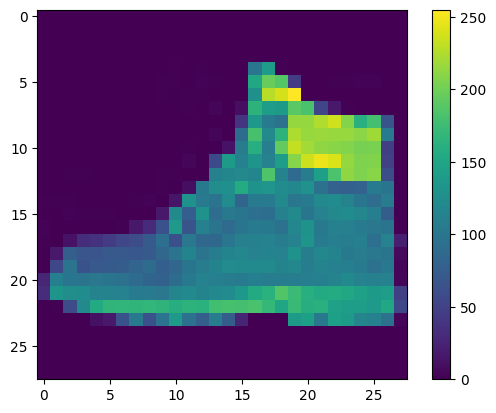

In [8]:
plt.figure()
plt.imshow(train_images[90])
plt.colorbar()
plt.grid(False)
plt.show()

In [ ]:
#we normalize the images to a range of 0 to 1 before feeding them to the neural network model.
#To do this, we divide the pixel values by 255.0 (the maximum value
train_images = train_images / 255.0

test_images = test_images / 255.0

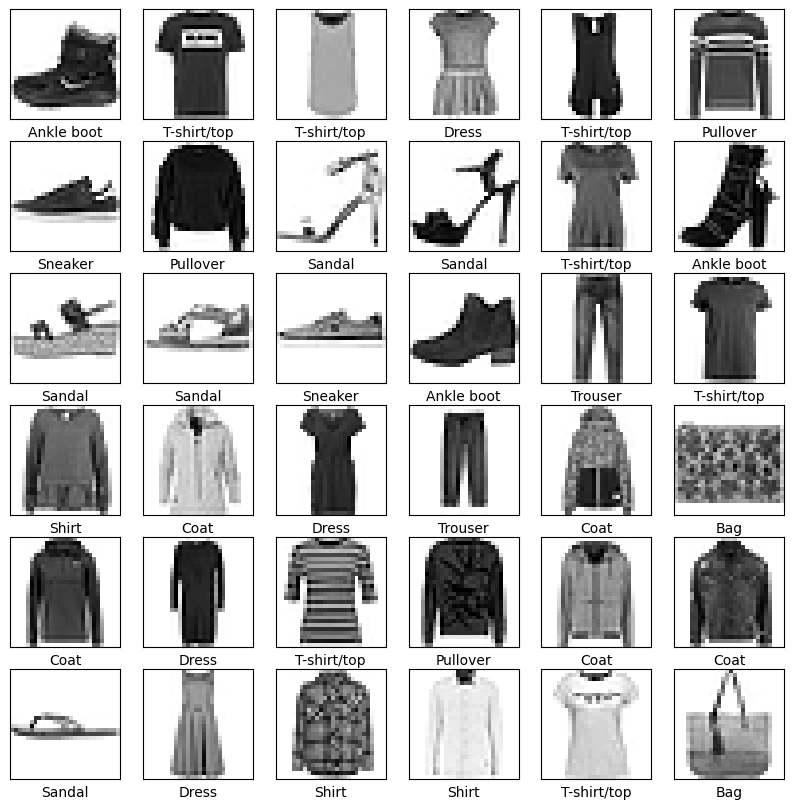

In [11]:
plt.figure(figsize=(10,10))
for i in range(36):
    plt.subplot(6,6,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10)
])

c:\Users\Pawnopoly\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [21]:
model.fit(train_images, train_labels, epochs=20)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.6595 - loss: 1.0920
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7691 - loss: 0.6436
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7937 - loss: 0.5706
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8112 - loss: 0.5290
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8226 - loss: 0.5009
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8303 - loss: 0.4811
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8356 - loss: 0.4658
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8400 - loss: 0.4537
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8436 - loss: 0.4437
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8466 - loss: 0.4353
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8495 - loss: 0.4281
Epoch 12/20
1875/1875 ━━━━━━━━

In [9]:
# Evaluate the model
# This will give us the loss and accuracy of the model on the test dataset.
# We can use this to evaluate the performance of the model.
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

NameError: name 'model' is not defined

In [23]:
# Create a probability model
# This model will output the probabilities of each class
# by applying a softmax activation to the output layer of the model.
probability_model = tf.keras.Sequential([model, 
                                         tf.keras.layers.Softmax()])


In [25]:
# Make predictions
# This will give us the probabilities of each class for each image in the test dataset.
predictions = probability_model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [27]:
# Function to plot the image, prediction, and true label
predictions[0]


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.], dtype=float32)

In [31]:
np.argmax(predictions[0])

np.int64(9)

In [32]:
# Function to plot the image, prediction, and true label
def plot_image(i, predictions_array, true_label, img):

  # This function plots the image, the predicted label, and the true label
  true_label, img = true_label[i], img[i]
  
  # Set up the plot
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  # Plot the image
  plt.imshow(img, cmap=plt.cm.binary)

  # Get the predicted label and color it based on whether it's correct
  predicted_label = np.argmax(predictions_array)

  # Set the color based on whether the prediction is correct
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

 # Plot the predicted label with the color
  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)
  
# Function to plot the value array
def plot_value_array(i, predictions_array, true_label):
  # This function plots the value array for the predictions
  true_label = true_label[i]

  # Set up the plot
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])

  # Plot the predictions array
  thisplot = plt.bar(range(10), predictions_array, color="#BEEA76")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

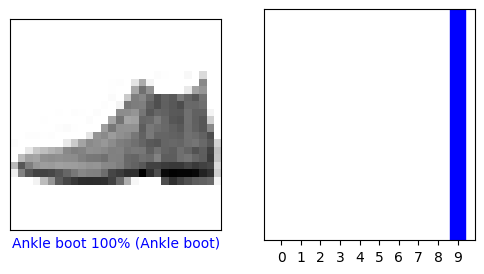

In [33]:
i = 0
plt.figure(figsize=(6,3))

# Plot the image, prediction, and true label
# Plot the image
# subplots represents the layout of the plots
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

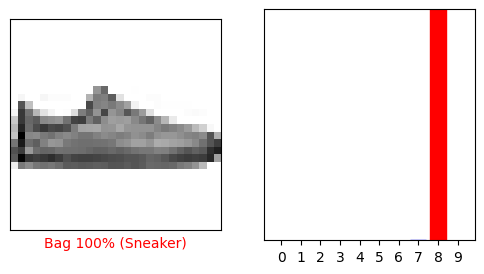

In [34]:
i = 12
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions[i], test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions[i],  test_labels)
plt.show()

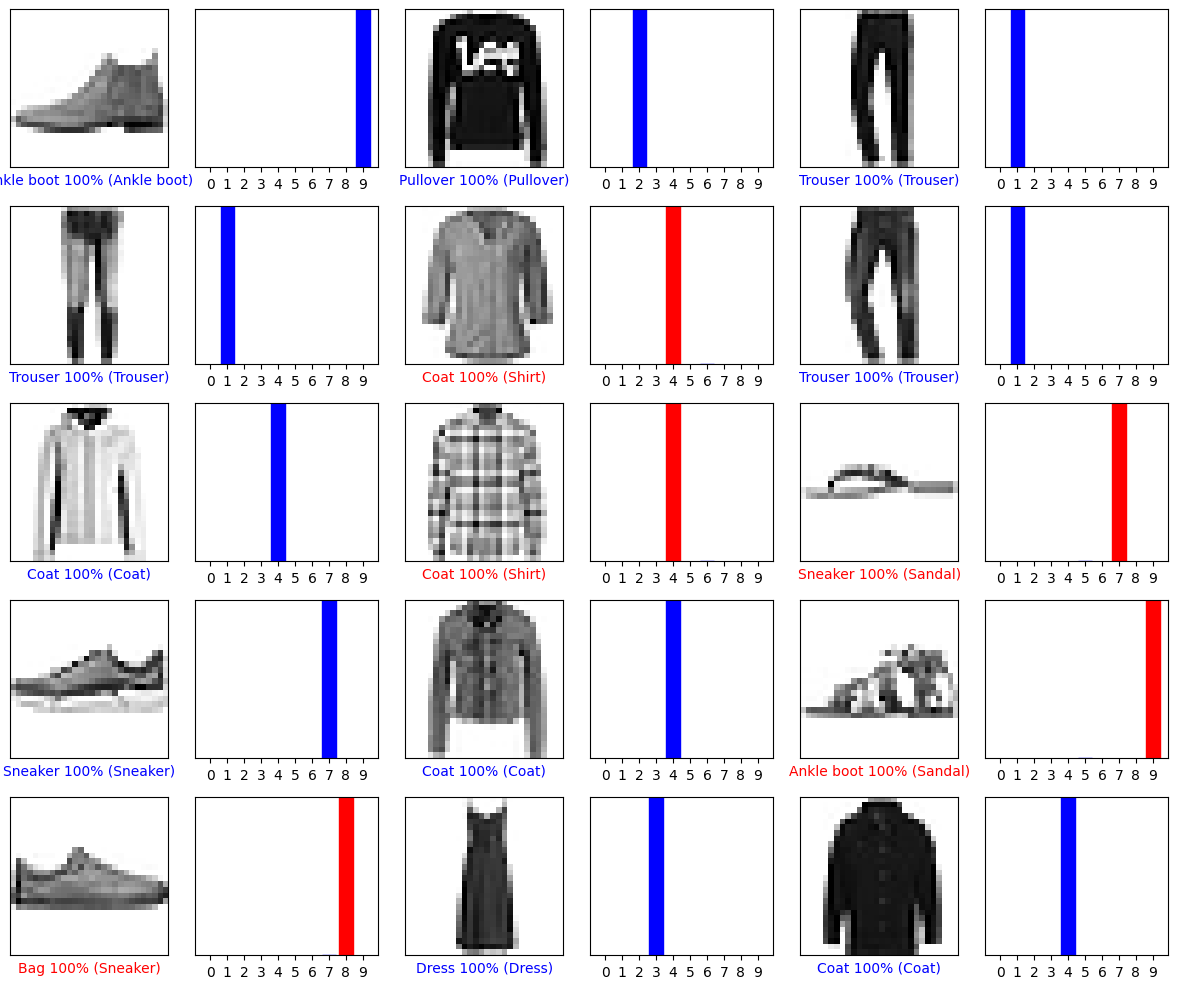

In [ ]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions[i], test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2) 
  plot_value_array(i, predictions[i], test_labels)
plt.tight_layout()
plt.show()

In [36]:
# Grab an image from the test dataset.
img = test_images[1]

print(img.shape)

(28, 28)


In [37]:
# Add the image to a batch where it's the only member.
img = (np.expand_dims(img,0))

print(img.shape)

(1, 28, 28)


In [38]:
predictions_single = probability_model.predict(img)

print(predictions_single)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]]


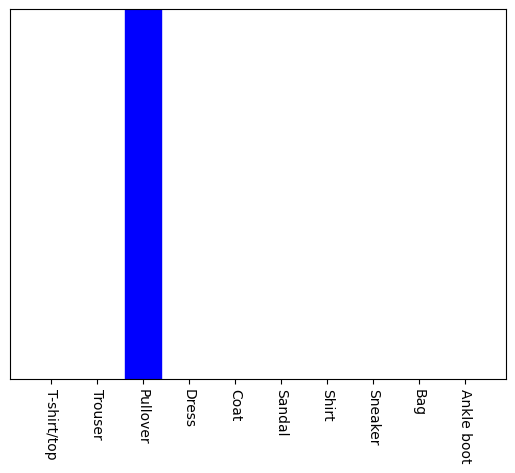

In [39]:
plot_value_array(1, predictions_single[0], test_labels)
_ = plt.xticks(range(10), class_names, rotation=-90)
plt.show()

In [40]:
np.argmax(predictions_single[0])

np.int64(2)